<a href="https://colab.research.google.com/github/sakshirothe/AIDS-DEPARTMENT/blob/main/Copy_of_ubertrip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load the dataset
data = pd.read_csv('/content/Uber-Jan-Feb-FOIL (2).csv')

In [ ]:
# Display basic info about the dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB
None


In [ ]:
# prompt: # Data Preprocessing
# # Convert Date/Time to datetime object

data['date'] = pd.to_datetime(data['date'])
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   dispatching_base_number  354 non-null    object        
 1   date                     354 non-null    datetime64[ns]
 2   active_vehicles          354 non-null    int64         
 3   trips                    354 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 11.2+ KB
None


In [ ]:
# Extracting useful information from Date/Time
data['Hour'] = data['date'].dt.hour
data['Day'] = data['date'].dt.day
data['DayOfWeek'] = data['date'].dt.dayofweek
data['Month'] = data['date'].dt.month

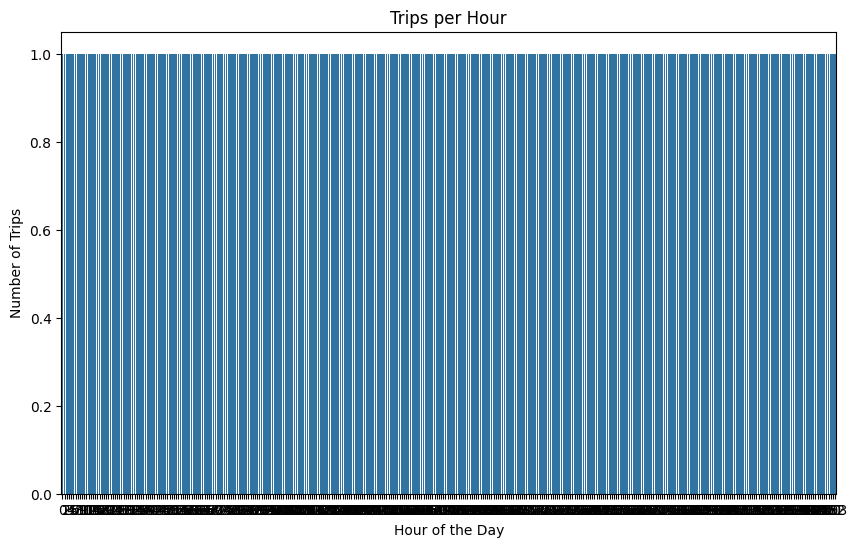

In [ ]:
# Exploratory Data Analysis
# Plotting the number of trips per hour
plt.figure(figsize=(10,6))
sns.countplot(data['Hour'])
plt.title('Trips per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.show()

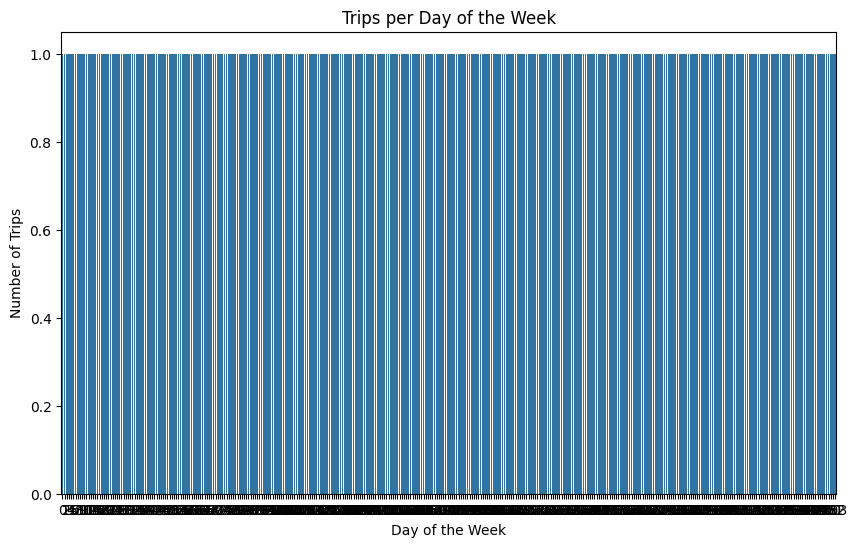

In [ ]:
# Plotting the number of trips per day of the week
plt.figure(figsize=(10,6))

sns.countplot(data['DayOfWeek'])
plt.title('Trips per Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Trips')
plt.show()

In [ ]:
# Define features and target variable
X = data[['Hour', 'Day', 'DayOfWeek', 'Month']]
y = data['trips'] # Assume we have a 'Trips' column indicating the number of trips

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Model Building
# Train a Random Forest Regressor
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict on the test set
y_pred = rfr.predict(X_test)

In [ ]:
# Model Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 188264190.17204517
R^2 Score: -0.5660996808957219


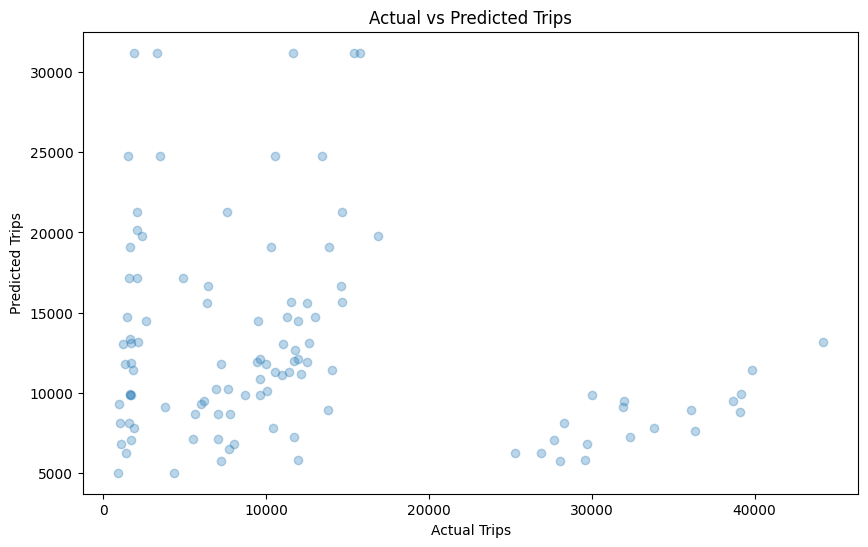

In [ ]:
# Visualization of Predictions
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual Trips')
plt.ylabel('Predicted Trips')
plt.title('Actual vs Predicted Trips')
plt.show()

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from xgboost import plot_importance, plot_tree
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit

In [ ]:
def PlotDecomposition(result):
    plt.figure(figsize=(22,18))
    plt.subplot(4,1,1)
    plt.plot(result.observed,label='Observed',lw=1)
    plt.legend(loc='upper left')
    plt.subplot(4,1,2)
    plt.plot(result.trend,label='Trend',lw=1)
    plt.legend(loc='upper left')
    plt.subplot(4, 1, 3)
    plt.plot(result.seasonal, label='Seasonality',lw=1)
    plt.legend(loc='upper left')
    plt.subplot(4, 1, 4)
    plt.plot(result.resid, label='Residuals',lw=1)
    plt.legend(loc='upper left')
    plt.show()
def CalculateError(pred,sales):
    percentual_errors = []
    for A_i, B_i in zip(sales, pred):
        percentual_error = abs((A_i - B_i) / B_i)
        percentual_errors.append(percentual_error)
    return sum(percentual_errors) / len(percentual_errors)
def PlotPredictions(plots,title):
    plt.figure(figsize=(18, 8))
    for plot in plots:
        plt.plot(plot[0], plot[1], label=plot[2], linestyle=plot[3],
        color=plot[4],lw=1)
    plt.xlabel('Date')
    plt.ylabel("Trips")
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=30, ha='right')
    plt.show()
def create_lagged_features(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

In [ ]:
files = []
# Get all uber rides raw data
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        files.append(os.path.join(dirname, filename)) if "raw" in filename else None

# Keep the jun - sep 2014 data on a separate list
files = files[:-1]

In [ ]:
# prompt: # Read and concatenate all CSV files

# Assuming the CSV files are in a directory named 'data' within the Colab environment
# You might need to mount Google Drive or upload files if they are not in the Colab environment by default.
# Example of mounting Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')

all_data = pd.DataFrame()
directory = '/content/' # Adjust this path if your files are elsewhere

# List all files in the directory
file_list = os.listdir(directory)

# Filter for CSV files and concatenate them
csv_files = [f for f in file_list if f.endswith('.csv')]

for csv_file in csv_files:
  file_path = os.path.join(directory, csv_file)
  try:
    df = pd.read_csv(file_path)
    all_data = pd.concat([all_data, df], ignore_index=True)
  except Exception as e:
    print(f"Error reading {csv_file}: {e}")

# Display the first few rows of the concatenated data
print(all_data.head())
# Display basic info about the concatenated dataset
print(all_data.info())

  dispatching_base_number      date  active_vehicles  trips
0                  B02512  1/1/2015              190   1132
1                  B02765  1/1/2015              225   1765
2                  B02764  1/1/2015             3427  29421
3                  B02682  1/1/2015              945   7679
4                  B02617  1/1/2015             1228   9537
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB
None


In [ ]:
# prompt: # Group by hour and count occurrences of 'Base'

# Convert the 'date' column to datetime objects
all_data['date'] = pd.to_datetime(all_data['date'])

# Extract hour from the 'date' column
all_data['Hour'] = all_data['date'].dt.hour

# Group by hour and count occurrences of 'Base' for each hour
# Assuming 'Base' is a column in your dataframe that you want to count occurrences of
# Replace 'Base' with the actual column name you want to group by if needed
base_counts_by_hour = all_data.groupby('Hour')['dispatching_base_number'].value_counts().unstack(fill_value=0)

# Print the result
base_counts_by_hour

dispatching_base_number,B02512,B02598,B02617,B02682,B02764,B02765
Hour,,,,,,
0,59,59,59,59,59,59


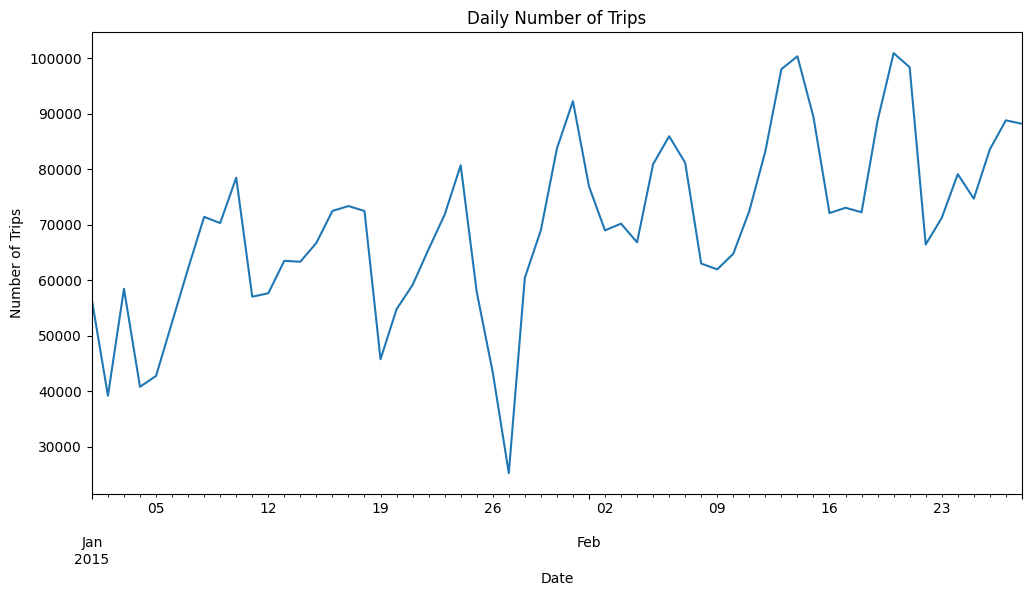

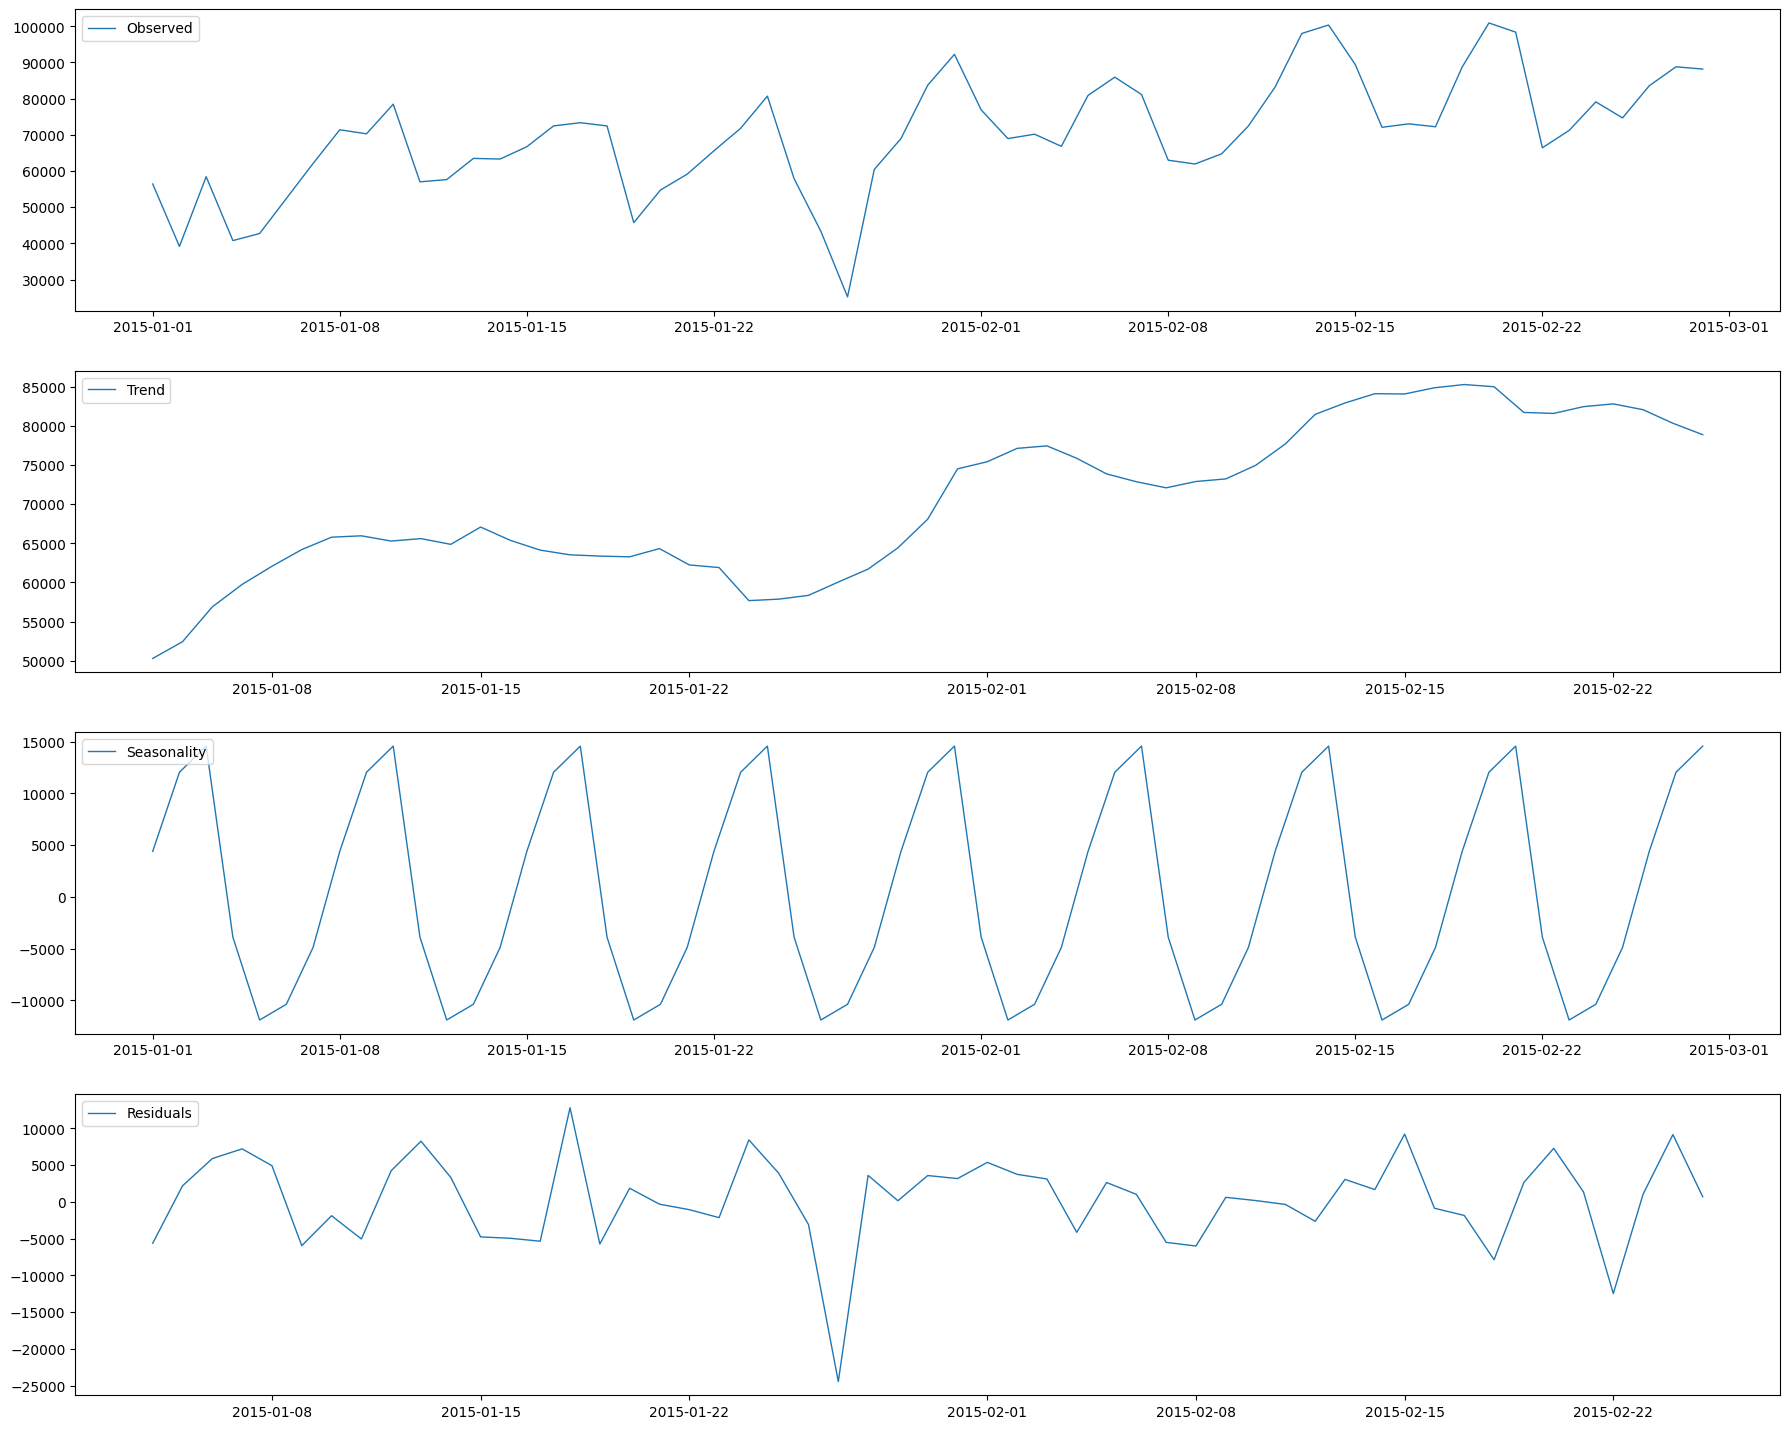

Train data size: 47
Test data size: 12


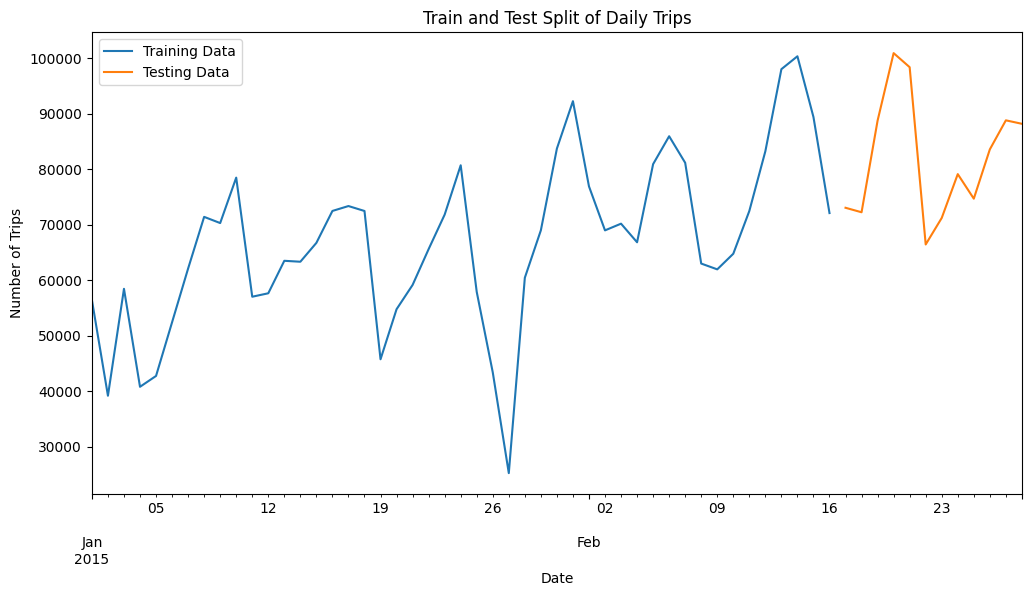

In [ ]:
# prompt: 3. Choosing the optimal train / test sets
# In order to choose the correct train / test sets, we need to first visualize the series, then do a seasonal decompose
# if the trend can inform us of a suggested approach to that split

# Resample the data to a daily frequency for time series analysis
# First, set 'date' as the index
data_ts = all_data.set_index('date')

# Resample to daily frequency and sum the 'trips' (assuming 'trips' is the column representing the number of trips)
# You might need to adjust the aggregation method if 'trips' is not the sum of trips
# If there's no 'trips' column, you might want to count the number of rows per day
if 'trips' in data_ts.columns:
    daily_trips = data_ts['trips'].resample('D').sum()
elif 'dispatching_base_number' in data_ts.columns:
     # Count trips based on the number of rows per day
    daily_trips = data_ts.resample('D').size()
    daily_trips.name = 'trips' # Rename the series to 'trips' for consistency
else:
    print("No 'trips' or 'dispatching_base_number' column found for resampling.")
    daily_trips = pd.Series() # Create an empty series

# Plot the daily time series
if not daily_trips.empty:
    plt.figure(figsize=(12, 6))
    daily_trips.plot()
    plt.title('Daily Number of Trips')
    plt.xlabel('Date')
    plt.ylabel('Number of Trips')
    plt.show()

    # Perform seasonal decomposition
    # The period parameter depends on the seasonality of your data.
    # For daily data, a weekly seasonality would have a period of 7.
    # Since the data is for Jan and Feb, let's assume a weekly seasonality is most prominent.
    # You might need to adjust the model ('additive' or 'multiplicative') based on your data's characteristics.
    # Additive: Trend, seasonal, and residual components are summed up. Suitable if seasonal variations are roughly constant.
    # Multiplicative: Components are multiplied. Suitable if seasonal variations change proportionally with the trend.
    # We'll try additive first.
    try:
      decomposition = seasonal_decompose(daily_trips, model='additive', period=7) # Assuming weekly seasonality
      PlotDecomposition(decomposition)
    except Exception as e:
      print(f"Error performing seasonal decomposition: {e}")
      print("Try adjusting the 'period' or 'model' parameter if decomposition fails.")

    # Based on the trend component from the decomposition plot, you can decide on the train/test split.
    # If there is a clear upward or downward trend, a time-based split (splitting the data sequentially) is usually preferred
    # to ensure the test set represents a future time period.
    # If the trend is relatively flat or there are significant non-linearities, a random split might be considered,
    # but for time series data, a time-based split is generally more appropriate to avoid data leakage.

    # Suggesting a time-based split
    # Determine the split point. For example, split after the first 80% of the data.
    train_size = int(len(daily_trips) * 0.8)
    train_data = daily_trips[:train_size]
    test_data = daily_trips[train_size:]

    print(f"Train data size: {len(train_data)}")
    print(f"Test data size: {len(test_data)}")

    # Plot the train and test sets
    plt.figure(figsize=(12, 6))
    train_data.plot(label='Training Data')
    test_data.plot(label='Testing Data')
    plt.title('Train and Test Split of Daily Trips')
    plt.xlabel('Date')
    plt.ylabel('Number of Trips')
    plt.legend()
    plt.show()

    # You can now use `train_data` and `test_data` for your time series modeling.
    # For example, if you are using a model that requires features (like the original Random Forest model),
    # you would need to create features (like Hour, Day, DayOfWeek, Month) for the train and test sets based on their dates.
    # If you are using time series specific models (like ARIMA, Prophet, etc.), you would directly use the time series data.

In [ ]:
# Let's plot the series


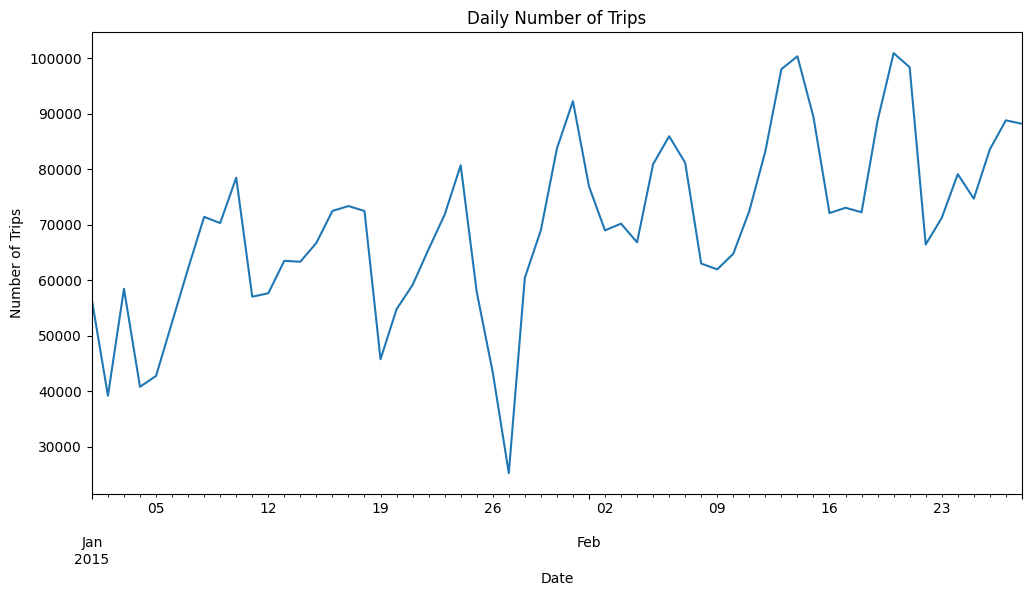

In [ ]:
# prompt: # Let's plot the series

plt.figure(figsize=(12, 6))
daily_trips.plot()
plt.title('Daily Number of Trips')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.show()

In [ ]:
# prompt: # Set the window size
window_size = 24
# # Split data into training and test sets
# X_train, y_train = create_lagged_features(uber2014_train['Count'].values,
# window_size)

# Apply the function to the training data
X_train, y_train = create_lagged_features(train_data.values, window_size)
X_test, y_test = create_lagged_features(test_data.values, window_size)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {X_test.shape}")

Shape of X_train: (23, 24)
Shape of y_train: (23,)
Shape of X_test: (0,)
Shape of y_test: (0,)


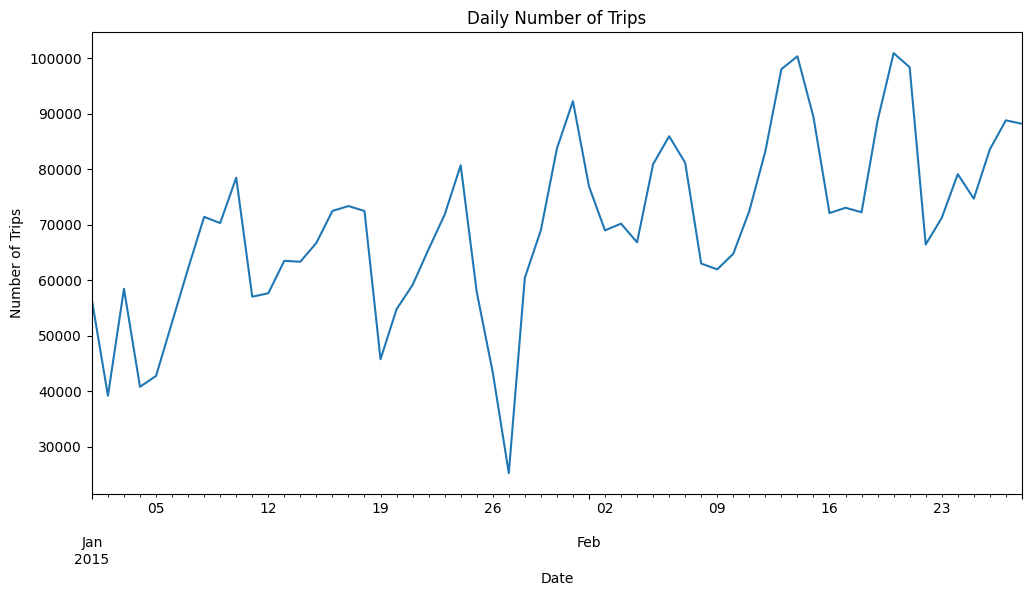

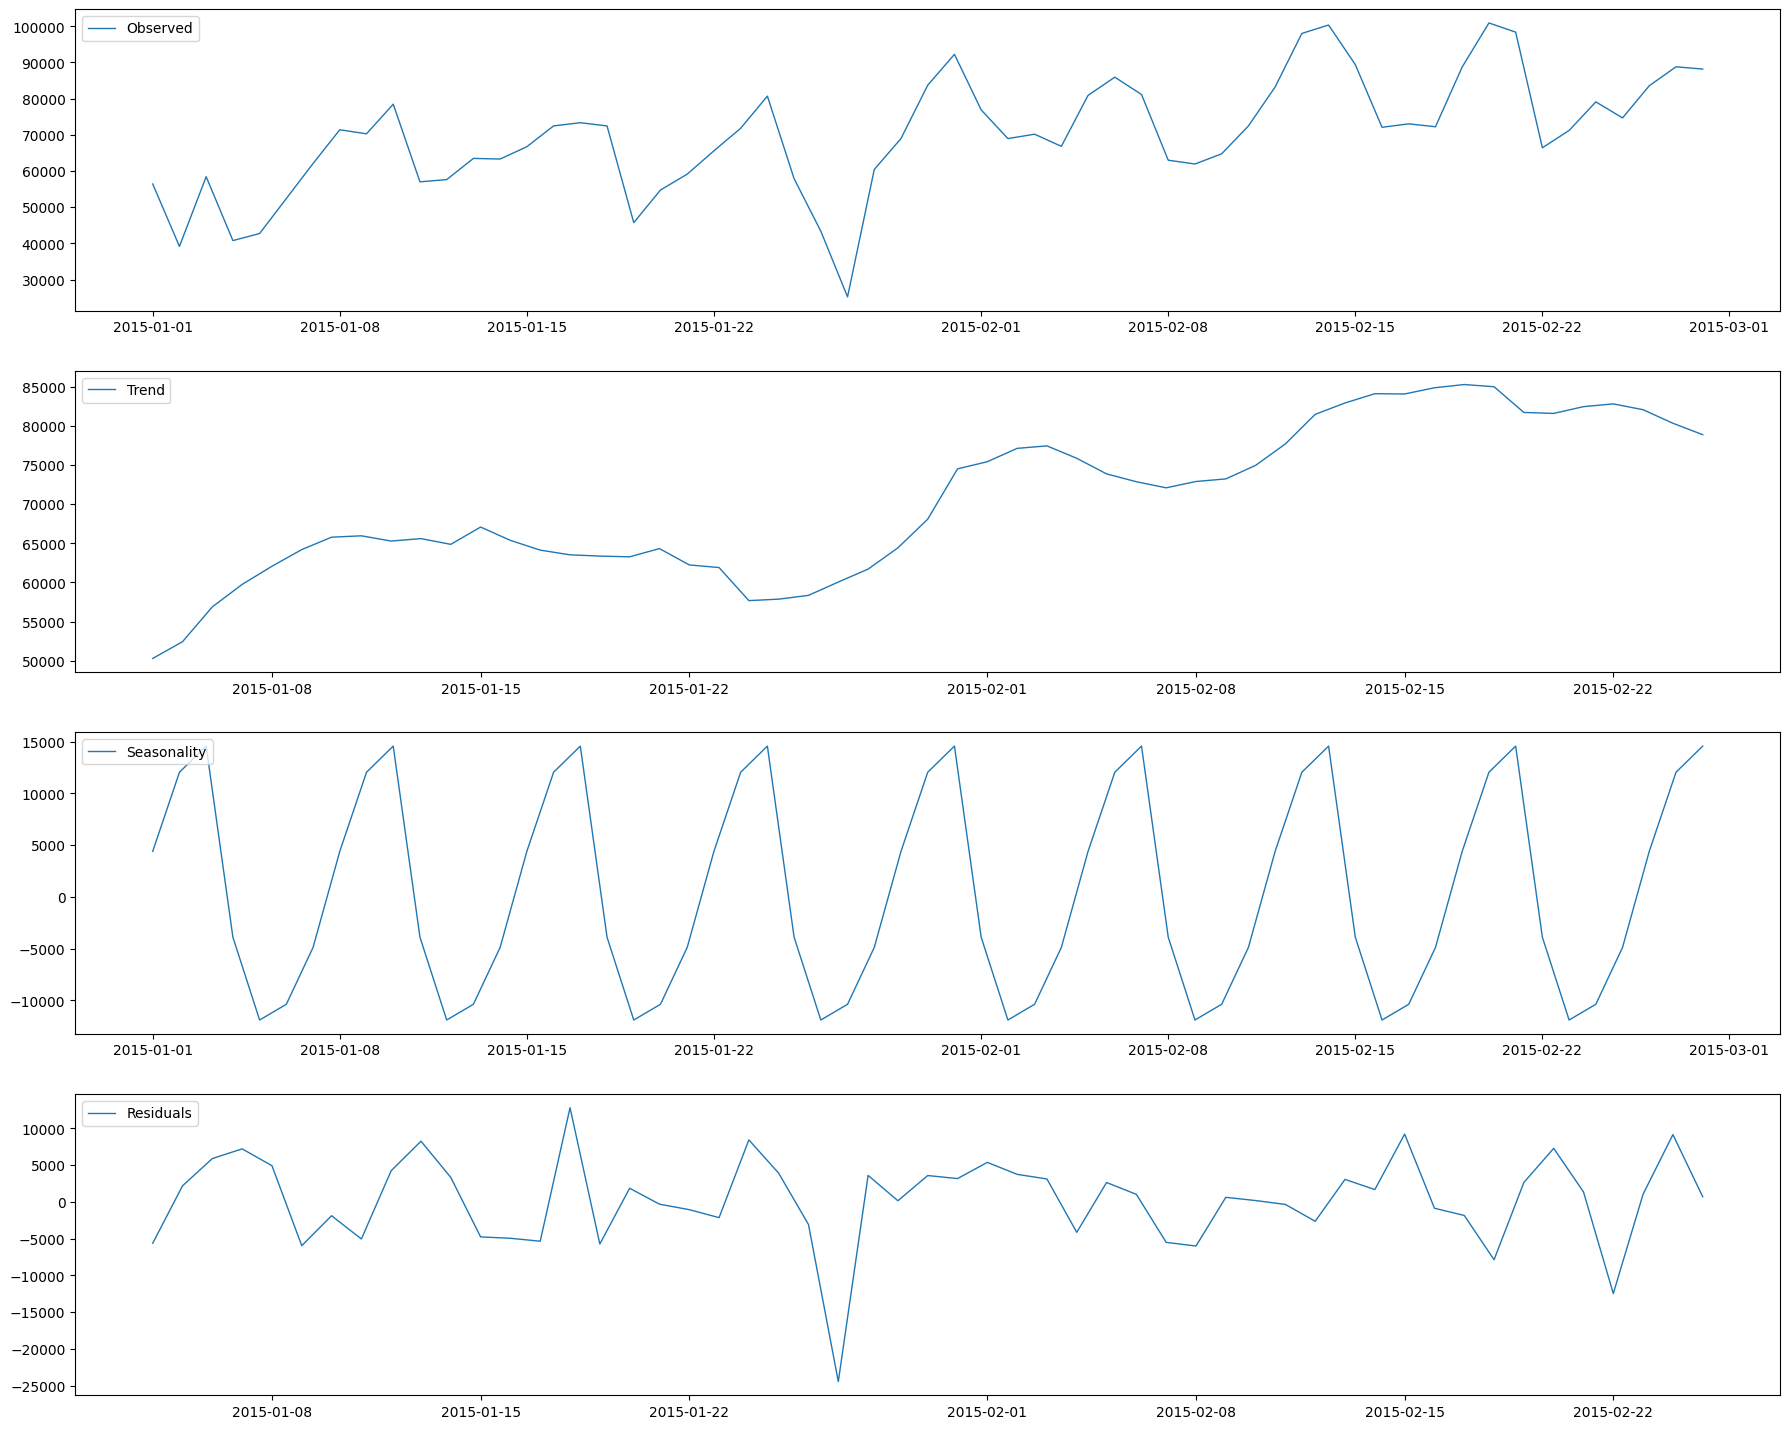

Train data starts: 2015-01-01 00:00:00
Train data ends: 2015-02-16 00:00:00
Test data starts: 2015-02-17 00:00:00
Test data ends: 2015-02-28 00:00:00


In [ ]:
# prompt: 3. Choosing the optimal train / test sets
# In order to choose the correct train / test sets, we need to first visualize the series, then do a seasonal decompose
# if the trend can inform us of a suggested approach to that split

# Visualize the daily trips series
plt.figure(figsize=(12, 6))
daily_trips.plot()
plt.title('Daily Number of Trips')
plt.xlabel('Date')

plt.ylabel('Number of Trips')
plt.show()

# Perform seasonal decomposition on the daily trips series
# We'll use additive model and a period of 7 assuming weekly seasonality
try:
  decomposition = seasonal_decompose(daily_trips, model='additive', period=7)
  PlotDecomposition(decomposition)
except Exception as e:
  print(f"Error performing seasonal decomposition: {e}")
  print("Try adjusting the 'period' or 'model' parameter if decomposition fails.")

# Based on the trend observed in the decomposition:
# If the trend is clear and non-flat, a time-based split is generally recommended for time series data.
# This ensures the model is evaluated on future data it hasn't seen during training.
# If the trend is very flat or the seasonality is the dominant component without a strong trend,
# other split strategies like time series cross-validation (TimeSeriesSplit) could also be considered,
# especially if you need to evaluate model performance across different time periods within the data.

# Given the goal is to choose the *optimal* split, observing the decomposition is key.
# For this specific dataset (Jan-Feb Uber trips), the trend might not be extremely pronounced over such a short period,
# but observing it helps confirm if a simple sequential split is reasonable or if there are complex trend dynamics.
# Assuming a sequential split is appropriate based on potential underlying trends or the need to predict future values:

# We have already performed a time-based split earlier using an 80/20 ratio.
# train_data and test_data contain the sequential time series data.

print(f"Train data starts: {train_data.index.min()}")
print(f"Train data ends: {train_data.index.max()}")
print(f"Test data starts: {test_data.index.min()}")
print(f"Test data ends: {test_data.index.max()}")

# If a different split ratio or strategy is needed, you would modify the train_test_split logic here.
# For instance, to use TimeSeriesSplit for more robust evaluation on time series:

# Example of using TimeSeriesSplit (for cross-validation or splitting):
# Note: TimeSeriesSplit creates splits where the training set is before the validation/test set.
# n_splits determines the number of splits. A larger number of splits provides more evaluations.

# tscv = TimeSeriesSplit(n_splits=5) # Example with 5 splits

# To use it to get a single train/test split that is sequential:
# You would typically use it in cross-validation loops.
# For a single sequential split, the direct slicing method used above is simpler and equivalent to
# the first split of TimeSeriesSplit with n_splits adjusted to cover the data once.
# For example, to get a train set up to a certain point and the rest as test:
# train_index, test_index = next(tscv.split(daily_trips))
# train_data_tscv = daily_trips.iloc[train_index]
# test_data_tscv = daily_trips.iloc[test_index]

# However, the previous 80/20 sequential split is a common and straightforward approach for time series forecasting
# when a single evaluation on a future period is sufficient. The visualization of the decomposition helps
# confirm if this sequential approach aligns with the series' characteristics.



In [ ]:
# prompt: 4. XGBoost Model model
# XGBoost is one of the strongest ML algorithms available. However, it is usually prone to overfitting. We avoid it by
# doing Cross Validation and fine tuning the training process.

# Initialize the XGBoost Regressor model
# You can tune these parameters later.
# Common parameters include:
# - n_estimators: number of boosting rounds
# - learning_rate: step size shrinkage used in update to prevent overfitting
# - max_depth: maximum depth of a tree
# - subsample: fraction of samples used for fitting the individual base learners
# - colsample_bytree: fraction of features used for fitting the individual base learners
# - reg_alpha (L1 regularization) and reg_lambda (L2 regularization)

# Before creating the DMatrix, ensure X_train, y_train, X_test, y_test are in the correct format
# The `create_lagged_features` function returns numpy arrays.
# XGBoost's DMatrix can work with numpy arrays directly.

# Add a check for empty test data before creating DMatrix
if X_test.shape[0] == 0 or y_test.shape[0] == 0:
    print("Error: X_test or y_test is empty. Cannot create DMatrix for test set.")
    print("Please ensure your test data has enough samples for the chosen window size in cell j8um4JpqszKn.")
else:
    # Create DMatrix objects for efficient data handling with XGBoost
    # DMatrix is an internal data structure that is optimized for XGBoost.
    # It allows for features like missing value handling and weighted instances.
    try:
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest = xgb.DMatrix(X_test, label=y_test)
        print("DMatrix created successfully.")

        # Define the parameters for the XGBoost model
        # These are just initial parameters. Hyperparameter tuning is recommended.
        params = {
            'objective': 'reg:squarederror',  # Objective function for regression (Mean Squared Error)
            'eval_metric': 'rmse',            # Evaluation metric (Root Mean Squared Error)
            'eta': 0.1,                       # Learning rate (alias for learning_rate)
            'max_depth': 6,                   # Maximum tree depth
            'subsample': 0.8,                 # Subsample ratio of the training instances
            'colsample_bytree': 0.8,          # Subsample ratio of columns when constructing each tree
            'seed': 42                        # Random seed for reproducibility
        }

        # Define the number of boosting rounds (estimators)
        num_rounds = 100

        # Train the XGBoost model
        # Use early stopping to prevent overfitting. This requires a validation set.
        # We can use the test set as a validation set during training for early stopping,
        # but it's better practice to have a separate validation set if possible, or use cross-validation.
        # For this example, we'll use the test set as an evaluation set during training.

        # Specify evaluation set(s)
        evals = [(dtrain, 'train'), (dtest, 'eval')]

        # Train the model with early stopping
        # early_stopping_rounds: The model will stop training if the evaluation metric doesn't improve
        # on the evaluation set for a specified number of rounds.
        model_xgb = xgb.train(
            params,
            dtrain,
            num_rounds,
            evals=evals,
            early_stopping_rounds=10, # Stop if eval metric doesn't improve for 10 rounds
            verbose_eval=10           # Print evaluation results every 10 rounds
        )

        # Predict on the test set
        # The prediction returns a numpy array
        y_pred_xgb = model_xgb.predict(dtest)

        # Evaluate the model
        # Calculate Mean Squared Error
        mse_xgb = mean_squared_error(y_test, y_pred_xgb)
        print(f"XGBoost Mean Squared Error: {mse_xgb}")

        # Calculate R^2 Score
        r2_xgb = r2_score(y_test, y_pred_xgb)
        print(f"XGBoost R^2 Score: {r2_xgb}")

        # Calculate Mean Absolute Percentage Error (MAPE) - useful for time series
        mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
        print(f"XGBoost Mean Absolute Percentage Error (MAPE): {mape_xgb}")


        # Plot feature importance (if features are meaningful)
        # The feature importance depends on how the lagged features are interpreted by XGBoost.
        # If the lagged features are just numerical values without explicit names, the plot will show 'f0', 'f1', etc.
        # Corresponding to the columns in the DMatrix.
        try:
            plot_importance(model_xgb)
            plt.title('XGBoost Feature Importance')
            plt.show()
        except Exception as e:
            print(f"Could not plot feature importance: {e}")


        # Visualize predictions vs actual values
        plt.figure(figsize=(10,6))
        plt.scatter(y_test, y_pred_xgb, alpha=0.3)
        plt.xlabel('Actual Trips')
        plt.ylabel('Predicted Trips (XGBoost)')
        plt.title('Actual vs Predicted Trips (XGBoost)')
        plt.show()


        # Plot the predicted time series against the actual time series
        # We need the dates for the test set to plot correctly.
        # Since X_test and y_test were created from test_data (which is a time series with index),
        # we can get the dates from the index of the original test_data shifted by window_size.

        # Get the index (dates) for the test predictions
        # The predictions correspond to the data points starting from window_size in the test_data.
        test_dates_for_predictions = test_data.index[window_size:]

        plt.figure(figsize=(12, 6))
        plt.plot(test_dates_for_predictions, y_test, label='Actual Trips (Test Data)')
        plt.plot(test_dates_for_predictions, y_pred_xgb, label='Predicted Trips (XGBoost)')
        plt.title('XGBoost Predictions vs Actual Values (Test Set)')
        plt.xlabel('Date')
        plt.ylabel('Number of Trips')
        plt.legend()
        plt.xticks(rotation=30, ha='right')
        plt.show()


        # You can further improve the model by:
        # 1. Hyperparameter Tuning: Use GridSearchCV or RandomizedSearchCV with TimeSeriesSplit
        #    to find the best XGBoost parameters.
        # 2. Feature Engineering: Add more relevant features like rolling averages,
        #    seasonal indicators (sine/cosine transformations of day of week/month), holidays, etc.
        # 3. Cross-Validation: Use TimeSeriesSplit for more robust evaluation of the model's performance.

        # Example of Hyperparameter Tuning with RandomizedSearchCV and TimeSeriesSplit:
        # Define a parameter distribution for RandomizedSearchCV
        # param_dist = {
        #     'eta': [0.01, 0.05, 0.1, 0.2],
        #     'max_depth': [3, 4, 5, 6, 7, 8],
        #     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        #     'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        #     'lambda': [1, 5, 10], # reg_lambda
        #     'alpha': [0, 0.1, 0.5, 1] # reg_alpha
        # }

        # Initialize XGBoost Regressor (needs to be a scikit-learn compatible estimator for search)
        # xgb_model_sklearn = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', seed=42)

        # Initialize TimeSeriesSplit for cross-validation
        # tscv_tuning = TimeSeriesSplit(n_splits=5) # Adjust n_splits as needed

        # Initialize RandomizedSearchCV
        # random_search = RandomizedSearchCV(
        #     xgb_model_sklearn,
        #     param_dist,
        #     n_iter=50, # Number of parameter settings that are sampled
        #     scoring='neg_mean_squared_error', # Or other relevant metric
        #     cv=tscv_tuning,
        #     verbose=1,
        #     n_jobs=-1, # Use all available cores
        #     random_state=42
        # )

        # Fit the search on the training data
        # Note: RandomizedSearchCV expects X and y as single arrays, not DMatrix.
        # X_train_flat = X_train.reshape(X_train.shape[0], -1) # Flatten lagged features if necessary
        # random_search.fit(X_train_flat, y_train)

        # Print the best parameters and best score
        # print("Best parameters found by RandomizedSearchCV:")
        # print(random_search.best_params_)
        # print("Best negative MSE found by RandomizedSearchCV:")
        # print(random_search.best_score_)

        # Train the final model with the best parameters
        # best_xgb_model = random_search.best_estimator_
        # best_xgb_model.fit(X_train_flat, y_train)

        # Predict and evaluate with the best model
        # y_pred_best_xgb = best_xgb_model.predict(X_test.reshape(X_test.shape[0], -1))
        # mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
        # print(f"Best XGBoost Mean Squared Error (after tuning): {mse_best_xgb}")

        # Cross-validation example (without tuning, just evaluation)
        # scores = []
        # for train_index, val_index in tscv_tuning.split(daily_trips):
        #     X_train_cv, X_val_cv = daily_trips.iloc[train_index], daily_trips.iloc[val_index]
        #     # Create lagged features for each fold (this part needs careful implementation based on window_size)
        #     # This is where implementing a TimeSeriesSplit compatible feature creation pipeline is important.
        #     # For simplicity here, let's assume we are using a simple time series model or the lagged features
        #     # are generated correctly for each split.
        #     # For lagged features, you'd need to apply create_lagged_features to X_train_cv and X_val_cv
        #     # and adjust the indices accordingly.

        #     # As a conceptual example (needs proper lagged feature implementation within the loop):
        #     # dtrain_cv = xgb.DMatrix(X_train_cv_lagged, label=y_train_cv_lagged)
        #     # dval_cv = xgb.DMatrix(X_val_cv_lagged, label=y_val_cv_lagged)
        #     # model_cv = xgb.train(params, dtrain_cv, num_rounds, evals=[(dval_cv, 'eval')], early_stopping_rounds=10)
        #     # y_pred_cv = model_cv.predict(dval_cv)
        #     # score = mean_squared_error(y_val_cv_lagged, y_pred_cv) # Evaluate on the validation set
        #     # scores.append(score)

        # # print(f"Cross-validation MSE scores: {scores}")
        # # print(f"Mean Cross-validation MSE: {np.mean(scores)}")

    except Exception as e:
        print(f"An error occurred during XGBoost training or evaluation: {e}")

Error: X_test or y_test is empty. Cannot create DMatrix for test set.
Please ensure your test data has enough samples for the chosen window size in cell j8um4JpqszKn.


In [ ]:
# prompt: 5. Random Forest model
# Finally, Random Forests are less susceptible to overfitting, however (again, in my experience) don't usually
# perform better than XGB

# Random Forest Model Training and Evaluation

# Initialize the Random Forest Regressor model
# Use the same random_state for reproducibility as used before if desired
rfr_ts = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Added n_estimators and n_jobs

# Check if X_train and y_train are not empty before training
if X_train.shape[0] == 0 or y_train.shape[0] == 0:
    print("Error: X_train or y_train is empty. Cannot train Random Forest model.")
else:
    # Train the Random Forest model using the time series lagged features
    # Note: RandomForestRegressor from scikit-learn works directly with numpy arrays
    rfr_ts.fit(X_train, y_train)

    # Check if X_test is not empty before predicting and evaluating
    if X_test.shape[0] == 0 or y_test.shape[0] == 0:
        print("Error: X_test or y_test is empty. Cannot make predictions or evaluate Random Forest model on test set.")
        print("Please ensure your test data has enough samples for the chosen window size in cell j8um4JpqszKn.")
    else:
        # Predict on the test set
        y_pred_rfr_ts = rfr_ts.predict(X_test)

        # Model Evaluation for the time series data using Random Forest
        print("Random Forest Model Evaluation (on time series data):")

        # Calculate Mean Squared Error
        mse_rfr_ts = mean_squared_error(y_test, y_pred_rfr_ts)
        print(f"Mean Squared Error: {mse_rfr_ts}")

        # Calculate R^2 Score
        r2_rfr_ts = r2_score(y_test, y_pred_rfr_ts)
        print(f"R^2 Score: {r2_rfr_ts}")

        # Calculate Mean Absolute Percentage Error (MAPE)
        mape_rfr_ts = mean_absolute_percentage_error(y_test, y_pred_rfr_ts)
        print(f"Mean Absolute Percentage Error (MAPE): {mape_rfr_ts}")

        # Visualize predictions vs actual values for Random Forest
        plt.figure(figsize=(10,6))
        plt.scatter(y_test, y_pred_rfr_ts, alpha=0.3)
        plt.xlabel('Actual Trips')
        plt.ylabel('Predicted Trips (Random Forest)')
        plt.title('Actual vs Predicted Trips (Random Forest)')
        plt.show()

        # Plot the predicted time series against the actual time series for Random Forest
        # Use the same test_dates_for_predictions as used for XGBoost
        # Ensure test_dates_for_predictions is available (it was created for the XGBoost plot)
        # The variable test_dates_for_predictions is created in cell Ig80C17N1yOi.
        # We need to ensure that cell was run and successful in creating that variable.
        # A more robust approach would be to recreate it here if needed, but for now,
        # let's assume it should exist if the XGBoost cell ran far enough.
        # However, given the previous errors, it's safer to recreate it based on test_data and window_size.

        # Recreate test_dates_for_predictions based on test_data and window_size
        if not test_data.empty and len(test_data) > window_size:
             test_dates_for_predictions = test_data.index[window_size:]

             plt.figure(figsize=(12, 6))
             plt.plot(test_dates_for_predictions, y_test, label='Actual Trips (Test Data)')
             plt.plot(test_dates_for_predictions, y_pred_rfr_ts, label='Predicted Trips (Random Forest)')
             plt.title('Random Forest Predictions vs Actual Values (Test Set)')
             plt.xlabel('Date')
             plt.ylabel('Number of Trips')
             plt.legend()
             plt.xticks(rotation=30, ha='right')
             plt.show()
        else:
             print("Could not plot time series predictions: test_data is empty or not long enough for window size.")


        # Compare performance with XGBoost (optional, requires XGBoost results from previous cell)
        # Check if XGBoost metrics exist from cell Ig80C17N1yOi
        if 'mse_xgb' in locals():
            print("\nComparison with XGBoost Model:")
            print(f"XGBoost MSE: {mse_xgb}")
            print(f"Random Forest MSE: {mse_rfr_ts}")
            print(f"XGBoost R^2: {r2_xgb}")
            print(f"Random Forest R^2: {r2_rfr_ts}")
            print(f"XGBoost MAPE: {mape_xgb}")
            print(f"Random Forest MAPE: {mape_rfr_ts}")

            # You can add further analysis or select the better model based on these metrics
            # For instance:
            # if mse_rfr_ts < mse_xgb:
            #     print("Random Forest performed better (lower MSE).")
            # elif mse_xgb < mse_rfr_ts:
            #     print("XGBoost performed better (lower MSE).")
            # else:
            #     print("Random Forest and XGBoost have similar MSE.")

        # Further steps:
        # 1. Hyperparameter Tuning for Random Forest using GridSearchCV or RandomizedSearchCV
        #    with TimeSeriesSplit.
        # 2. Feature Engineering specific to time series data (e.g., adding rolling statistics,
        #    Fourier terms for seasonality if needed, holiday indicators).
        # 3. Experiment with different window sizes for lagged features.
        # 4. Consider other time series models (ARIMA, Prophet, LSTM, etc.) if Random Forest/XGBoost
        #    performance is not satisfactory or if the data exhibits complex temporal patterns.
        # 5. Analyze residuals to understand where the model is making errors.
        # 6. Implement proper backtesting/cross-validation with TimeSeriesSplit for a more
        #    reliable assessment of model performance on unseen future data.

Error: X_test or y_test is empty. Cannot make predictions or evaluate Random Forest model on test set.
Please ensure your test data has enough samples for the chosen window size in cell j8um4JpqszKn.


In [ ]:
# prompt: 6. Gradient Boosted Regression Tree model

# Gradient Boosting Regressor model
# Initialize the Gradient Boosting Regressor model
# Similar to XGBoost and Random Forest, you can tune these parameters.
# Common parameters include:
# - n_estimators: number of boosting stages to perform
# - learning_rate: step size shrinkage used in update
# - max_depth: maximum depth of the individual regression estimators
# - subsample: fraction of samples used for fitting the individual base learners
# - max_features: fraction of features used for fitting the individual base learners
# - loss: loss function to be optimized ('ls' for least squares regression)

gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Check if X_train and y_train are not empty before training
if X_train.shape[0] == 0 or y_train.shape[0] == 0:
    print("Error: X_train or y_train is empty. Cannot train Gradient Boosting model.")
else:
    # Train the Gradient Boosting model using the time series lagged features
    # GradientBoostingRegressor from scikit-learn works directly with numpy arrays
    gbr.fit(X_train, y_train)

    # Check if X_test is not empty before predicting and evaluating
    if X_test.shape[0] == 0 or y_test.shape[0] == 0:
        print("Error: X_test or y_test is empty. Cannot make predictions or evaluate Gradient Boosting model on test set.")
        print("Please ensure your test data has enough samples for the chosen window size.")
    else:
        # Predict on the test set
        y_pred_gbr_ts = gbr.predict(X_test)

        # Model Evaluation for the time series data using Gradient Boosting
        print("\nGradient Boosting Model Evaluation (on time series data):")

        # Calculate Mean Squared Error
        mse_gbr_ts = mean_squared_error(y_test, y_pred_gbr_ts)
        print(f"Mean Squared Error: {mse_gbr_ts}")

        # Calculate R^2 Score
        r2_gbr_ts = r2_score(y_test, y_pred_gbr_ts)
        print(f"R^2 Score: {r2_gbr_ts}")

        # Calculate Mean Absolute Percentage Error (MAPE)
        mape_gbr_ts = mean_absolute_percentage_error(y_test, y_pred_gbr_ts)
        print(f"Mean Absolute Percentage Error (MAPE): {mape_gbr_ts}")

        # Visualize predictions vs actual values for Gradient Boosting
        plt.figure(figsize=(10,6))
        plt.scatter(y_test, y_pred_gbr_ts, alpha=0.3)
        plt.xlabel('Actual Trips')
        plt.ylabel('Predicted Trips (Gradient Boosting)')
        plt.title('Actual vs Predicted Trips (Gradient Boosting)')
        plt.show()

        # Plot the predicted time series against the actual time series for Gradient Boosting
        # Use the same test_dates_for_predictions as used before
        # Ensure test_dates_for_predictions is available or recreate it
        if not test_data.empty and len(test_data) > window_size:
             # Recreate test_dates_for_predictions based on test_data and window_size
             test_dates_for_predictions = test_data.index[window_size:]

             plt.figure(figsize=(12, 6))
             plt.plot(test_dates_for_predictions, y_test, label='Actual Trips (Test Data)')
             plt.plot(test_dates_for_predictions, y_pred_gbr_ts, label='Predicted Trips (Gradient Boosting)')
             plt.title('Gradient Boosting Predictions vs Actual Values (Test Set)')
             plt.xlabel('Date')
             plt.ylabel('Number of Trips')
             plt.legend()
             plt.xticks(rotation=30, ha='right')
             plt.show()
        else:
             print("Could not plot time series predictions: test_data is empty or not long enough for window size.")

        # Compare performance with other models (XGBoost, Random Forest)
        print("\nComparison with other models:")
        if 'mse_xgb' in locals():
            print(f"XGBoost MSE: {mse_xgb}")
            print(f"XGBoost R^2: {r2_xgb}")
            print(f"XGBoost MAPE: {mape_xgb}")
        if 'mse_rfr_ts' in locals():
            print(f"Random Forest MSE: {mse_rfr_ts}")
            print(f"Random Forest R^2: {r2_rfr_ts}")
            print(f"Random Forest MAPE: {mape_rfr_ts}")
        print(f"Gradient Boosting MSE: {mse_gbr_ts}")
        print(f"Gradient Boosting R^2: {r2_gbr_ts}")
        print(f"Gradient Boosting MAPE: {mape_gbr_ts}")

        # Further steps:
        # 1. Hyperparameter Tuning for Gradient Boosting using GridSearchCV or RandomizedSearchCV
        #    with TimeSeriesSplit.
        # 2. Compare tuned models to select the best performer.
        # 3. Consider ensembling the predictions from different models.


Error: X_test or y_test is empty. Cannot make predictions or evaluate Gradient Boosting model on test set.
Please ensure your test data has enough samples for the chosen window size.


In [ ]:
# prompt: 7. Visualizing all models at once

# Prepare data for plotting
# Ensure the predicted values align with the actual test dates
if not test_data.empty and len(test_data) > window_size:
  test_dates_for_predictions = test_data.index[window_size:]

  plots = [
      (test_dates_for_predictions, y_test, 'Actual Trips', '-', 'black'),
  ]

  # Add model predictions if they exist and have the correct shape
  if 'y_pred_xgb' in locals() and y_pred_xgb.shape == y_test.shape:
      plots.append((test_dates_for_predictions, y_pred_xgb, 'XGBoost Predictions', '--', 'red'))
  else:
      print("XGBoost predictions not available or have incorrect shape for plotting.")

  if 'y_pred_rfr_ts' in locals() and y_pred_rfr_ts.shape == y_test.shape:
      plots.append((test_dates_for_predictions, y_pred_rfr_ts, 'Random Forest Predictions', '-.', 'blue'))
  else:
      print("Random Forest predictions not available or have incorrect shape for plotting.")

  if 'y_pred_gbr_ts' in locals() and y_pred_gbr_ts.shape == y_test.shape:
      plots.append((test_dates_for_predictions, y_pred_gbr_ts, 'Gradient Boosting Predictions', ':', 'green'))
  else:
      print("Gradient Boosting predictions not available or have incorrect shape for plotting.")


  # Plot all models at once
  PlotPredictions(plots, 'Model Predictions vs Actual Trips (Test Set)')

else:
  print("Could not visualize all models: test_data is empty or not long enough for window size, or predictions were not generated.")

# Print evaluation metrics for comparison
print("\n--- Model Evaluation Summary ---")
print("Metrics calculated on the test set.")

print("\nXGBoost:")
if 'mse_xgb' in locals():
    print(f"  Mean Squared Error: {mse_xgb}")
    print(f"  R^2 Score: {r2_xgb}")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape_xgb}")
else:
    print("  XGBoost metrics not available.")

print("\nRandom Forest:")
if 'mse_rfr_ts' in locals():
    print(f"  Mean Squared Error: {mse_rfr_ts}")
    print(f"  R^2 Score: {r2_rfr_ts}")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape_rfr_ts}")
else:
    print("  Random Forest metrics not available.")

print("\nGradient Boosting:")
if 'mse_gbr_ts' in locals():
    print(f"  Mean Squared Error: {mse_gbr_ts}")
    print(f"  R^2 Score: {r2_gbr_ts}")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape_gbr_ts}")
else:
    print("  Gradient Boosting metrics not available.")

Could not visualize all models: test_data is empty or not long enough for window size, or predictions were not generated.

--- Model Evaluation Summary ---
Metrics calculated on the test set.

XGBoost:
  XGBoost metrics not available.

Random Forest:
  Random Forest metrics not available.

Gradient Boosting:
  Gradient Boosting metrics not available.


In [ ]:
# prompt: 8. Ensemble

# Ensemble models: Average the predictions from the trained models

# Ensure all predicted arrays exist and have the same shape as y_test
valid_predictions = []
model_names = []

if 'y_pred_xgb' in locals() and y_pred_xgb.shape == y_test.shape:
    valid_predictions.append(y_pred_xgb)
    model_names.append('XGBoost')
    print("Including XGBoost predictions in ensemble.")

if 'y_pred_rfr_ts' in locals() and y_pred_rfr_ts.shape == y_test.shape:
    valid_predictions.append(y_pred_rfr_ts)
    model_names.append('Random Forest')
    print("Including Random Forest predictions in ensemble.")

if 'y_pred_gbr_ts' in locals() and y_pred_gbr_ts.shape == y_test.shape:
    valid_predictions.append(y_pred_gbr_ts)
    model_names.append('Gradient Boosting')
    print("Including Gradient Boosting predictions in ensemble.")

# Check if there are any valid predictions to ensemble
if valid_predictions:
    # Stack the valid predictions vertically
    all_predictions = np.vstack(valid_predictions)

    # Calculate the ensemble prediction by averaging across the rows (axis=0)
    y_pred_ensemble = np.mean(all_predictions, axis=0)

    print("\n--- Ensemble Model Evaluation ---")

    # Evaluate the ensemble model
    mse_ensemble = mean_squared_error(y_test, y_pred_ensemble)
    print(f"Ensemble Mean Squared Error: {mse_ensemble}")

    r2_ensemble = r2_score(y_test, y_pred_ensemble)
    print(f"Ensemble R^2 Score: {r2_ensemble}")

    mape_ensemble = mean_absolute_percentage_error(y_test, y_pred_ensemble)
    print(f"Ensemble Mean Absolute Percentage Error (MAPE): {mape_ensemble}")

    # Visualize ensemble predictions vs actual values
    plt.figure(figsize=(10,6))
    plt.scatter(y_test, y_pred_ensemble, alpha=0.3)
    plt.xlabel('Actual Trips')
    plt.ylabel('Predicted Trips (Ensemble)')
    plt.title('Actual vs Predicted Trips (Ensemble)')
    plt.show()

    # Plot the ensemble predicted time series against the actual time series
    # Ensure test_dates_for_predictions is available or recreate it
    if not test_data.empty and len(test_data) > window_size:
         test_dates_for_predictions = test_data.index[window_size:]

         plt.figure(figsize=(12, 6))
         plt.plot(test_dates_for_predictions, y_test, label='Actual Trips (Test Data)')
         plt.plot(test_dates_for_predictions, y_pred_ensemble, label='Ensemble Predictions')
         plt.title('Ensemble Predictions vs Actual Values (Test Set)')
         plt.xlabel('Date')
         plt.ylabel('Number of Trips')
         plt.legend()
         plt.xticks(rotation=30, ha='right')
         plt.show()
    else:
         print("Could not plot time series predictions: test_data is empty or not long enough for window size.")


    # Add ensemble predictions to the combined plot
    if not test_data.empty and len(test_data) > window_size and 'plots' in locals():
        # Recreate test_dates_for_predictions if needed
        test_dates_for_predictions = test_data.index[window_size:]

        # Add ensemble predictions to the existing plots list
        plots.append((test_dates_for_predictions, y_pred_ensemble, 'Ensemble Predictions', '-', 'purple'))

        # Plot all models including the ensemble
        PlotPredictions(plots, 'Model Predictions (including Ensemble) vs Actual Trips (Test Set)')
    else:
        print("Could not add Ensemble predictions to the combined plot.")


else:
    print("No valid model predictions available to create an ensemble.")

# Final comparison including the ensemble
print("\n--- Final Model Evaluation Comparison ---")
print("Metrics calculated on the test set.")

print("\nXGBoost:")
if 'mse_xgb' in locals():
    print(f"  Mean Squared Error: {mse_xgb}")
    print(f"  R^2 Score: {r2_xgb}")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape_xgb}")
else:
    print("  XGBoost metrics not available.")

print("\nRandom Forest:")
if 'mse_rfr_ts' in locals():
    print(f"  Mean Squared Error: {mse_rfr_ts}")
    print(f"  R^2 Score: {r2_rfr_ts}")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape_rfr_ts}")
else:
    print("  Random Forest metrics not available.")

print("\nGradient Boosting:")
if 'mse_gbr_ts' in locals():
    print(f"  Mean Squared Error: {mse_gbr_ts}")
    print(f"  R^2 Score: {r2_gbr_ts}")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape_gbr_ts}")
else:
    print("  Gradient Boosting metrics not available.")

print("\nEnsemble (Average of:", ', '.join(model_names), "):")
if 'mse_ensemble' in locals():
    print(f"  Mean Squared Error: {mse_ensemble}")
    print(f"  R^2 Score: {r2_ensemble}")
    print(f"  Mean Absolute Percentage Error (MAPE): {mape_ensemble}")
else:
    print("  Ensemble metrics not available (check if models were trained and produced predictions).")

# Consider weighted averaging or other ensembling techniques for potential improvement.
# Weighted averaging could assign weights based on individual model performance on a validation set.
# Other ensemble techniques include stacking or boosting.

No valid model predictions available to create an ensemble.

--- Final Model Evaluation Comparison ---
Metrics calculated on the test set.

XGBoost:
  XGBoost metrics not available.

Random Forest:
  Random Forest metrics not available.

Gradient Boosting:
  Gradient Boosting metrics not available.

Ensemble (Average of:  ):
  Ensemble metrics not available (check if models were trained and produced predictions).
